<a href="https://colab.research.google.com/github/selimhatipoglu/softito_egitim/blob/main/SoftITo/Classification/Mushroom_DecisionTree_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
columns = [
    "class",
    "cap_shape",
    "cap_surface",
    "cap_color",
    "bruises",
    "odor",
    "gill_attachment",
    "gill_spacing",
    "gill_size",
    "gill_color",
    "stalk_shape",
    "stalk_root",
    "stalk_surface_above_ring",
    "stalk_surface_below_ring",
    "stalk_color_above_ring",
    "stalk_color_below_ring",
    "veil_type",
    "veil_color",
    "ring_number",
    "ring_type",
    "spore_print_color",
    "population",
    "habitat"
]

In [3]:
df = pd.read_csv(
    "/content/agaricus-lepiota.data",
    header=None,
    names=columns
)

df.head()

,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
X = df.drop("class", axis=1)
y = df["class"]

In [5]:
display(X.head())
display(y.head())

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


,class
0,p
1,e
2,e
3,p
4,e


In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
X.shape

(8124, 95)

In [8]:
SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

In [9]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6499, 95)
X_test: (1625, 95)
y_train: (6499,)
y_test: (1625,)


In [10]:
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64
class
e    0.517926
p    0.482074
Name: proportion, dtype: float64
class
e    0.518154
p    0.481846
Name: proportion, dtype: float64


In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid={
        "criterion": ["gini", "entropy"],
        "splitter": ["best", "random"],
        "max_depth": [3, 4, 5, 6, 8, None],
        "min_samples_leaf": [1, 2, 5, 10]
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

dt = dt_grid.best_estimator_

print("En iyi parametreler:", dt_grid.best_params_)
print("En iyi CV accuracy:", dt_grid.best_score_)

En iyi parametreler: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 1, 'splitter': 'best'}
En iyi CV accuracy: 0.9996923076923077


Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



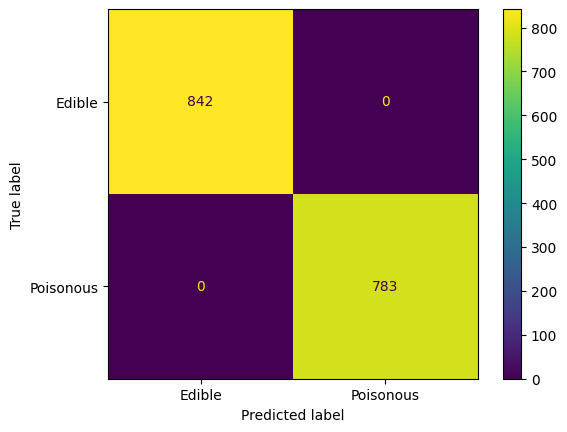

In [12]:
y_pred = dt.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Edible", "Poisonous"]
)

plt.show()

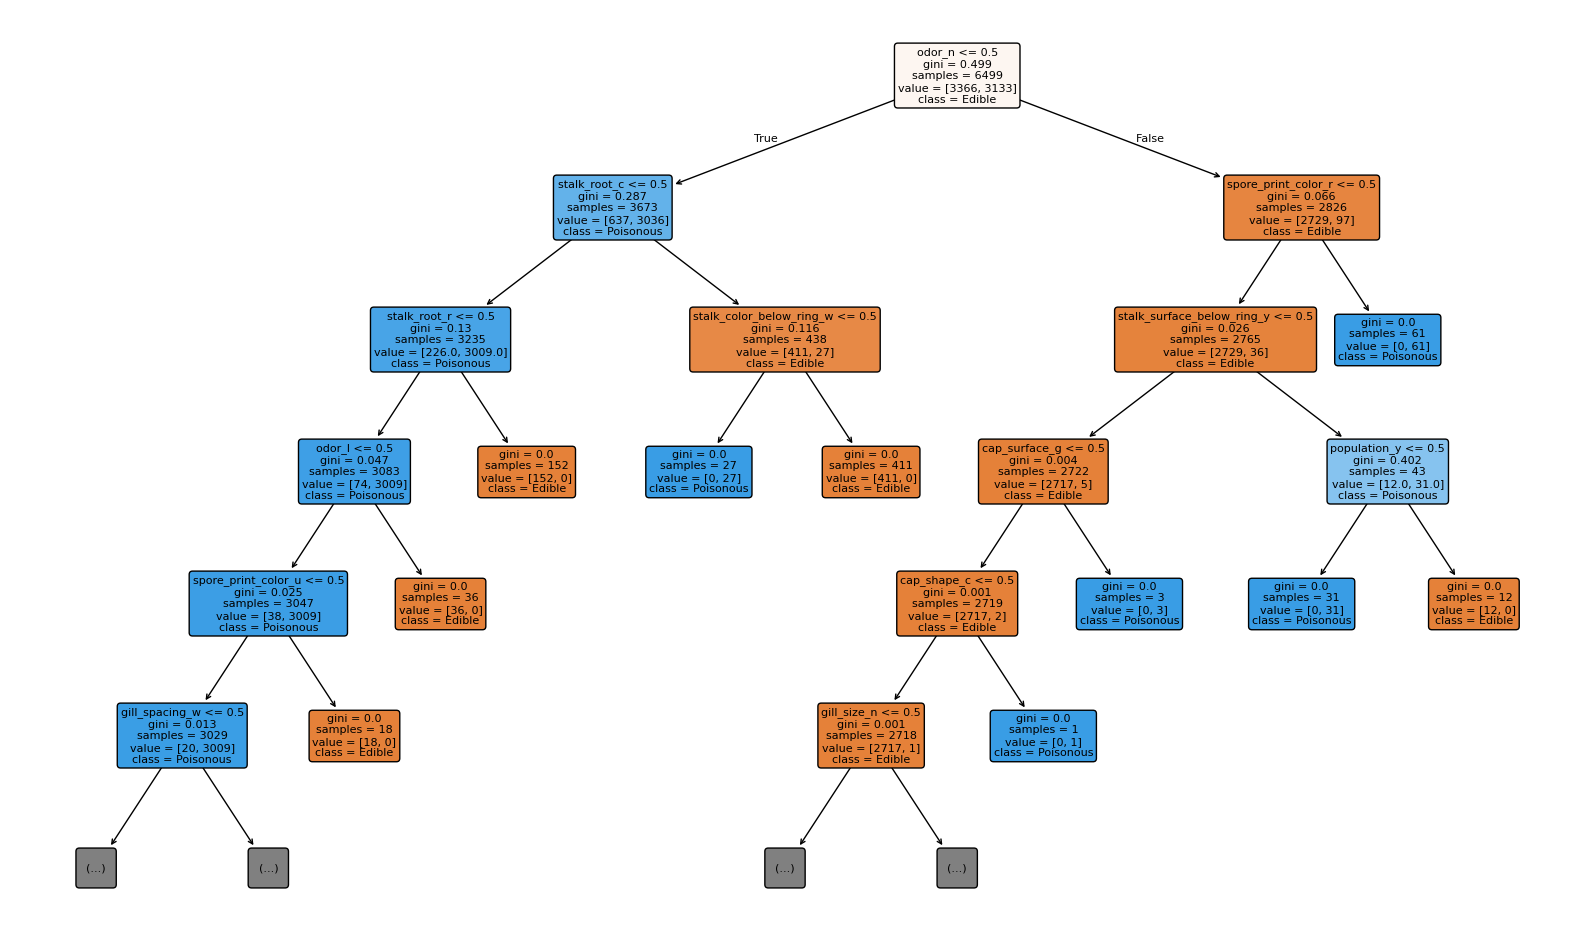

In [16]:
plt.figure(figsize=(20, 12))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Edible", "Poisonous"],
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize=8
)

plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED),

    param_grid={
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 8, 10, None],
        "min_samples_leaf": [1, 2, 5],
        "max_features": ["sqrt", "log2"]
    },

    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf = rf_grid.best_estimator_

print("En iyi parametreler:", rf_grid.best_params_)
print("En iyi CV accuracy:", rf_grid.best_score_)

En iyi parametreler: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
En iyi CV accuracy: 1.0


In [18]:
for name, model in [
    ("Decision Tree", dt),
    ("Random Forest", rf)
]:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    print(f"\n======== {name} ========")
    print(f"Test doğruluğu: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Ortalama 5 katlı CV doğruluğu: {np.mean(cv_scores):.4f}")


======== Decision Tree ========
Test doğruluğu: 1.0000
Ortalama 5 katlı CV doğruluğu: 0.9997

======== Random Forest ========
Test doğruluğu: 1.0000
Ortalama 5 katlı CV doğruluğu: 1.0000


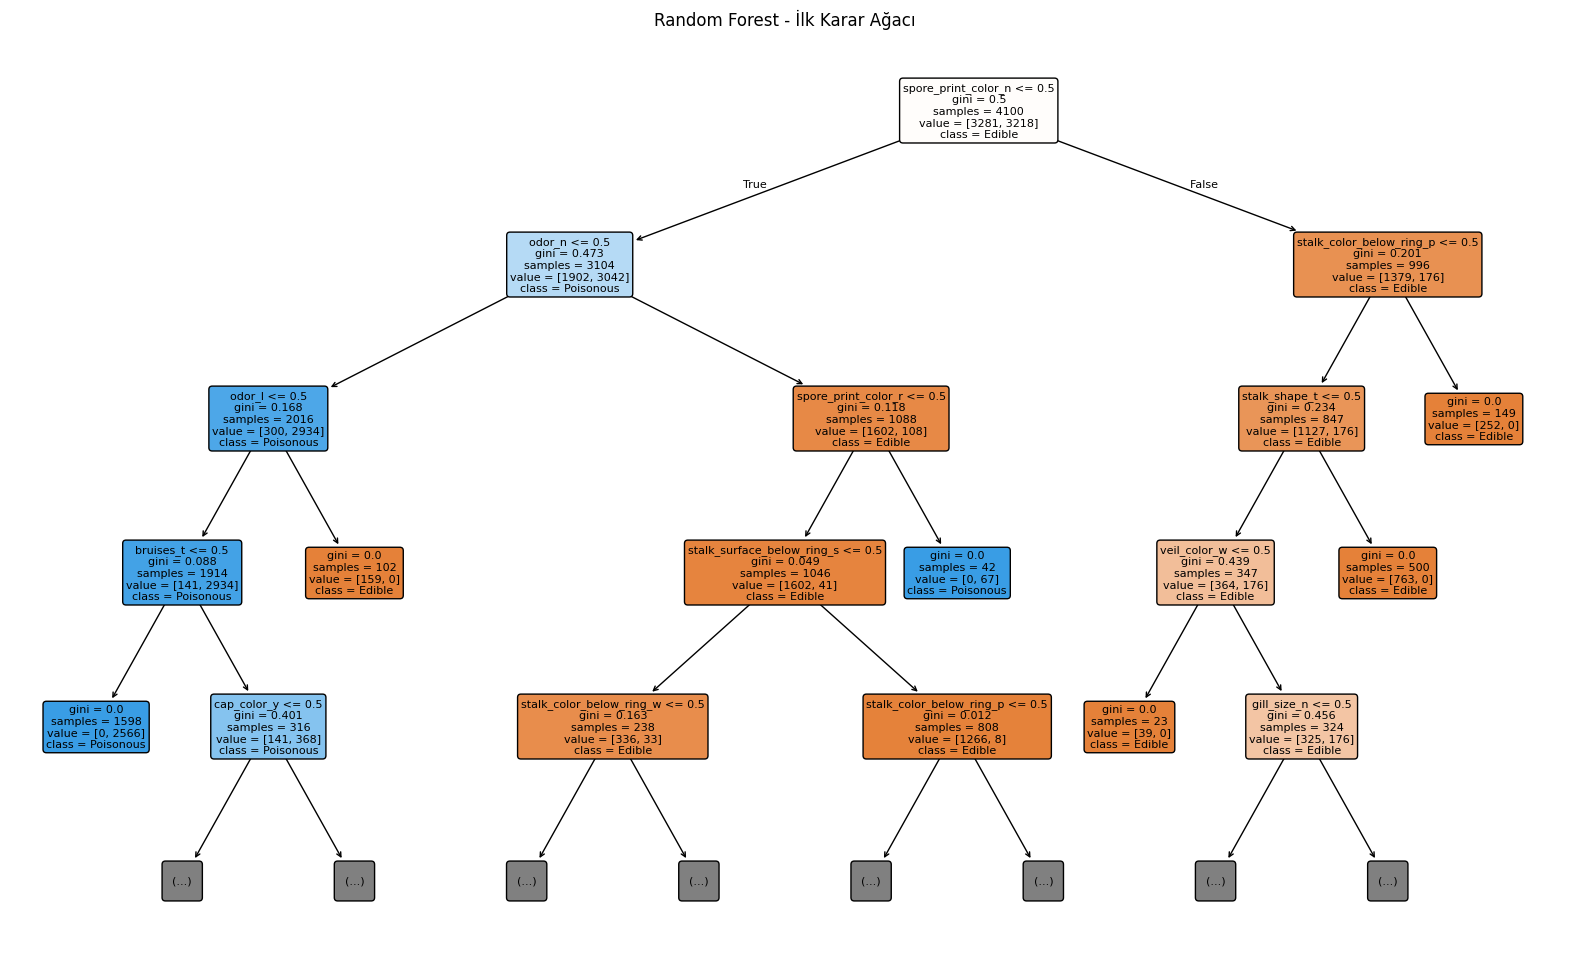

In [19]:
plt.figure(figsize=(20, 12))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["Edible", "Poisonous"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8
)

plt.title("Random Forest - İlk Karar Ağacı")
plt.show()